# Pretrain Log Inspection

Plot final training loss at step 2000 against learning rate, weight decay, and depth scaling for the AdamW and Muon sweeps.

In [277]:
from pathlib import Path
import matplotlib.pyplot as plt
# use retina mode
%config InlineBackend.figure_format = 'retina'
import numpy as np
from IPython.display import Markdown, display
import os

def format_figure(ax, fontsize):
    for a in ax:
        a.grid(
            True,
            which="major",
            color="0.75",
            linewidth=1.0,
            alpha=0.45,
            zorder=0,
        )
        a.set_axisbelow(True)

        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

        # Make remaining spines thick and black
        a.spines["left"].set_linewidth(1.0)
        a.spines["bottom"].set_linewidth(1.0)
        a.spines["left"].set_color("black")
        a.spines["bottom"].set_color("black")

        # Tick style: outward, thick, black
        a.tick_params(
            axis="both",
            which="major",
            direction="out",
            length=3,
            width=1.0,
            colors="black",
            pad=1,
            labelsize=fontsize
        )
        a.spines["left"].set_position(("outward", 5))
        a.spines["bottom"].set_position(("outward", 5))


def uniform_filter1d_numpy(x, size, mode="reflect"):
    """
    NumPy implementation of a 1D uniform / box filter.

    Parameters
    ----------
    x : array-like, shape (n,)
        Input 1D signal.
    size : int
        Window size.
    mode : {"reflect", "nearest", "wrap", "constant"}
        Boundary handling.

    Returns
    -------
    y : np.ndarray, shape (n,)
        Smoothed signal.
    """
    x = np.asarray(x)

    if x.ndim != 1:
        raise ValueError("x must be a 1D array")
    if size < 1:
        raise ValueError("size must be >= 1")

    left = size // 2
    right = size - left - 1

    if mode == "reflect":
        x_pad = np.pad(x, (left, right), mode="reflect")
    elif mode == "nearest":
        x_pad = np.pad(x, (left, right), mode="edge")
    elif mode == "wrap":
        x_pad = np.pad(x, (left, right), mode="wrap")
    elif mode == "constant":
        x_pad = np.pad(x, (left, right), mode="constant", constant_values=0)
    else:
        raise ValueError(f"Unsupported mode: {mode}")

    cumsum = np.cumsum(x_pad, dtype=float)
    cumsum = np.concatenate([[0.0], cumsum])

    return (cumsum[size:] - cumsum[:-size]) / size

In [278]:
LOG_DIR = Path("/home/xwang457/work/nanomoe/pretrain_log")
TARGET_STEP = 2000
TARGET_GRAD_ACCUM = 16
TARGET_WEIGHT_DECAYS = {0.01}  # Set to None, {0.01}, or {0.1} to filter decay sweeps.
TARGET_DEPTH_SCALING = None  # Set to {True} or {False} to filter depth scaling.
FINAL_LOSS_XLIM = (1e-4, 3e-2)  # Set to None to show all learning rates.
ROUTER_PLOT_WEIGHT_DECAY = 0.01
ROUTER_PLOT_DEPTH_SCALING = True
FILE_PREFIX = "opt-*"
OPTIMIZERS = {"adamw", "muon"}

In [279]:
LOG_DIR = Path("/home/xwang457/work/nanomoe/pretrain_log_with_ckpt")
TARGET_STEP = 2000
# TARGET_GRAD_ACCUM = 20
# TARGET_GRAD_ACCUM = 32
TARGET_GRAD_ACCUM = 48
TARGET_WEIGHT_DECAYS = {0.01}  # Set to None, {0.01}, or {0.1} to filter decay sweeps.
TARGET_DEPTH_SCALING = None  # Set to {True} or {False} to filter depth scaling.
FINAL_LOSS_XLIM = (1e-4, 3e-2)  # Set to None to show all learning rates.
ROUTER_PLOT_WEIGHT_DECAY = 0.01
ROUTER_PLOT_DEPTH_SCALING = True
FILE_PREFIX = "data-finewebedu_seed-42_opt-*"
OPTIMIZERS = {"adamw", "muon"}

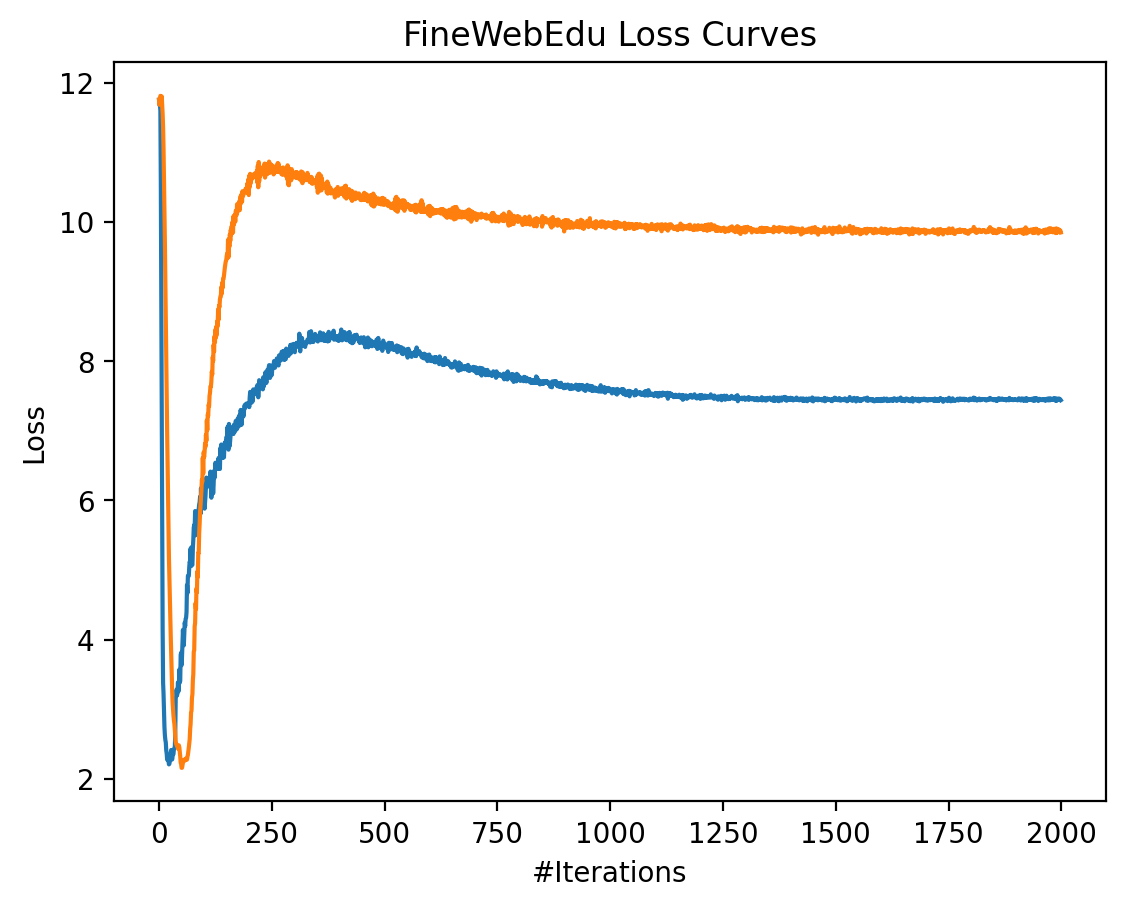

In [283]:
# plt.legend()
plt.xlabel('#Iterations')
plt.ylabel('Loss')
plt.title('FineWebEdu Loss Curves')

base_dir = '/home/xwang457/work/nanomoe/pretrain_log_with_ckpt/data-finewebedu_seed-42_opt-adamw_lr-0p001_wd-0p01_steps-2000_ga-48_warmup-100_hm-100_depth-0'
metric = np.load(base_dir + '/train_metrics.npy', allow_pickle=True).item()
plt.plot(2 ** metric['router_monitor'].mean(-1))

base_dir = '/home/xwang457/work/nanomoe/pretrain_log_with_ckpt/data-finewebedu_seed-42_opt-muon_lr-0p001_wd-0p01_steps-2000_ga-48_warmup-100_hm-100_depth-0'
metric = np.load(base_dir + '/train_metrics.npy', allow_pickle=True).item()
plt.plot(2 ** metric['router_monitor'].mean(-1))


# plt.ylim(1, 2)

In [1]:
base_dir = '/home/xwang457/work/nanomoe/pretrain_log/opt-muon_lr-0p0003_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-0'
metric = np.load(base_dir + '/train_metrics.npy', allow_pickle=True).item()
plt.plot(metric['loss'], alpha=0.9)
print(metric['loss'][-1])

base_dir = '/home/xwang457/work/nanomoe/pretrain_log/opt-adamw_lr-0p0003_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1'
metric = np.load(base_dir + '/train_metrics.npy', allow_pickle=True).item()
plt.plot(metric['loss'], alpha=0.9)
print(metric['loss'][-1])

base_dir = '/home/xwang457/work/nanomoe/pretrain_log/opt-muon_lr-0p0003_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1'
metric = np.load(base_dir + '/train_metrics.npy', allow_pickle=True).item()
plt.plot(metric['loss'], alpha=0.9)
print(metric['loss'][-1])
# plt.ylim(1, 2)

NameError: name 'np' is not defined

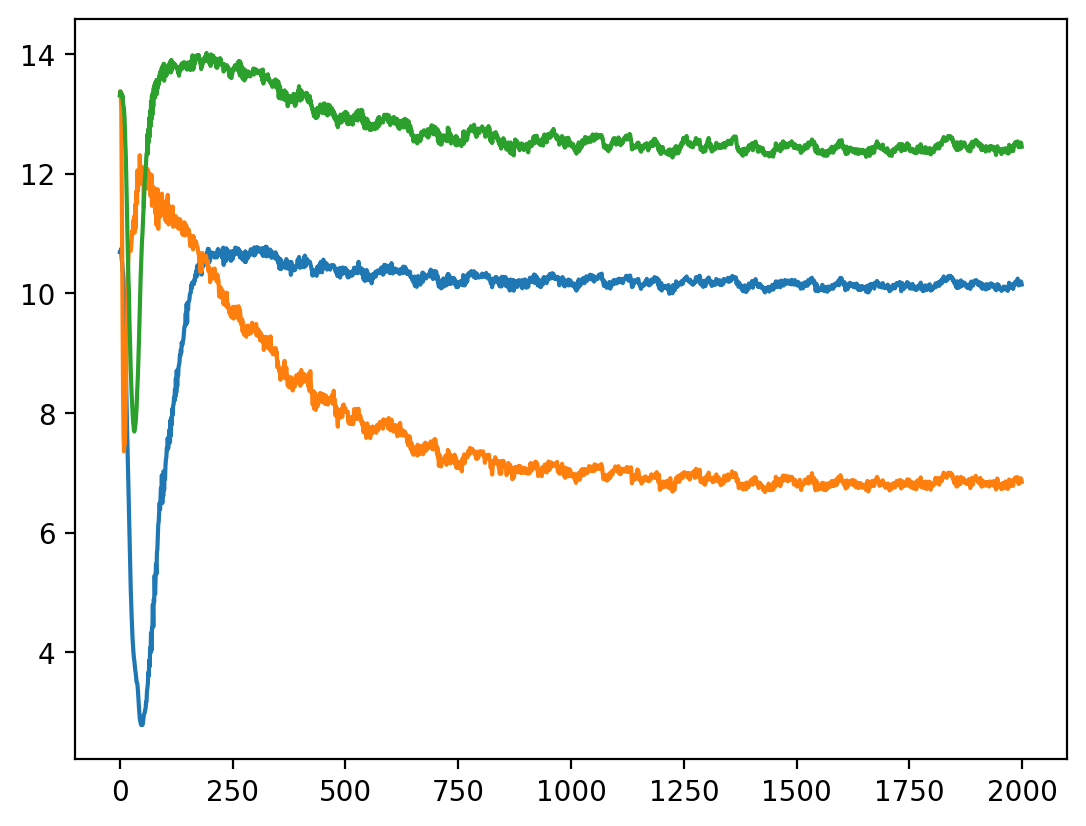

In [17]:
base_dir = '/home/xwang457/work/nanomoe/pretrain_log/opt-muon_lr-0p001_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-0'
metric = np.load(base_dir + '/train_metrics.npy', allow_pickle=True).item()
plt.plot(2 ** metric['router_monitor'].mean(-1))

base_dir = '/home/xwang457/work/nanomoe/pretrain_log/opt-adamw_lr-0p001_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1'
metric = np.load(base_dir + '/train_metrics.npy', allow_pickle=True).item()
plt.plot(2 ** metric['router_monitor'].mean(-1))

base_dir = '/home/xwang457/work/nanomoe/pretrain_log/opt-muon_lr-0p001_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1'
metric = np.load(base_dir + '/train_metrics.npy', allow_pickle=True).item()
plt.plot(2 ** metric['router_monitor'].mean(-1))

In [83]:
def load_final_loss_rows(log_dir: Path) -> tuple[list[dict], list[dict]]:
    rows = []
    skipped = []
    all_metrics = {}
    all_hidden_state_metrics = {}
    target_weight_decays = None if TARGET_WEIGHT_DECAYS is None else {float(wd) for wd in TARGET_WEIGHT_DECAYS}
    target_depth_scaling = None if TARGET_DEPTH_SCALING is None else {bool(value) for value in TARGET_DEPTH_SCALING}
    for run_dir in sorted(log_dir.glob(FILE_PREFIX)):
    # for run_dir in sorted(log_dir.glob("opt-*")):
        config_path = run_dir / "config.npy"
        metrics_path = run_dir / "train_metrics.npy"
        hidden_state_metrics_path = run_dir / "hidden_state_metrics.npy"
        if not config_path.exists() or not metrics_path.exists() or not hidden_state_metrics_path.exists():
            skipped.append({"run": run_dir.name, "reason": "missing config.npy or train_metrics.npy or hidden_state_metrics.npy"})
            continue

        config = np.load(config_path, allow_pickle=True).item()
        metrics = np.load(metrics_path, allow_pickle=True).item()
        hidden_state_metrics = np.load(hidden_state_metrics_path, allow_pickle=True).item()
        
        optimizer = config.get("optimizer")
        learning_rate = float(config["learning_rate"])
        weight_decay = float(config.get("weight_decay", 0.0))
        use_depth_scaling = bool(config.get("use_depth_scaling", "depth-1" in run_dir.name))
        depth_label = f"depth-{int(use_depth_scaling)}"
        iterations = int(config.get("iterations", -1))
        grad_accum = int(config.get("grad_accum", -1))
        if optimizer not in OPTIMIZERS:
            skipped.append({"run": run_dir.name, "reason": f"optimizer={optimizer!r}"})
            continue
        if iterations != TARGET_STEP:
            skipped.append({"run": run_dir.name, "reason": f"iterations={iterations}"})
            continue
        if grad_accum != TARGET_GRAD_ACCUM:
            skipped.append({"run": run_dir.name, "reason": f"grad_accum={grad_accum}"})
            continue
        if target_weight_decays is not None and weight_decay not in target_weight_decays:
            skipped.append({"run": run_dir.name, "reason": f"weight_decay={weight_decay:g}"})
            continue
        if target_depth_scaling is not None and use_depth_scaling not in target_depth_scaling:
            skipped.append({"run": run_dir.name, "reason": depth_label})
            continue

        steps = np.asarray(metrics["step"], dtype=int)
        losses = np.asarray(metrics["loss"], dtype=float)
        step_matches = np.flatnonzero(steps == TARGET_STEP)
        if len(step_matches) == 0:
            last_step = int(steps[-1]) if len(steps) else None
            skipped.append({"run": run_dir.name, "reason": f"no metric at step {TARGET_STEP}; last_step={last_step}"})
            continue
        run_key = (optimizer, learning_rate, weight_decay, use_depth_scaling)
        all_metrics[run_key] = metrics
        all_hidden_state_metrics[run_key] = hidden_state_metrics
        final_idx = int(step_matches[-1])
        rows.append(
            {
                "optimizer": optimizer,
                "learning_rate": learning_rate,
                "weight_decay": weight_decay,
                "lr_weight_decay": learning_rate * weight_decay,
                "weight_decay_label": f"wd={weight_decay:g}",
                "use_depth_scaling": use_depth_scaling,
                "depth": int(use_depth_scaling),
                "depth_label": depth_label,
                "series": f"{optimizer}, {depth_label}, wd={weight_decay:g}",
                "final_loss": float(losses[final_idx]),
                "step": int(steps[final_idx]),
                "grad_accum": grad_accum,
                "run": run_dir.name,
            }
        )

    rows.sort(key=lambda row: (row["optimizer"], row["depth"], row["weight_decay"], row["learning_rate"]))
    skipped.sort(key=lambda row: row["run"])
    return rows, skipped, all_metrics, all_hidden_state_metrics


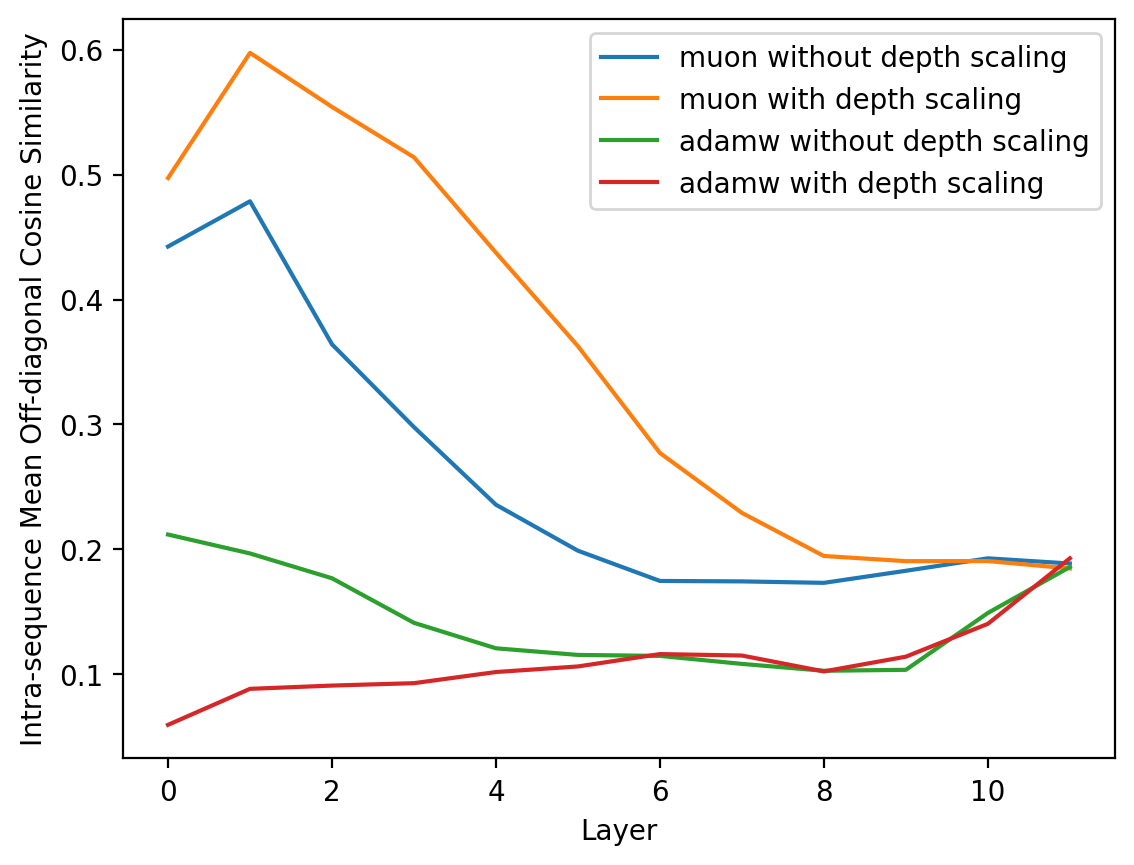

In [92]:
# COS = all_hidden_state_metrics[("adamw", 3e-3, ROUTER_PLOT_WEIGHT_DECAY, True)]["neighbouring_mean_token_cosine"]
# for c in COS[::4]:
#     plt.plot(c)

KEY = 'intra_sequence_mean_off_diagonal_cosine'

IDX = -1
lr = 1e-3

COS = all_hidden_state_metrics[("muon", lr, ROUTER_PLOT_WEIGHT_DECAY, False)][KEY]
plt.plot(COS[IDX], label='muon without depth scaling')

COS = all_hidden_state_metrics[("muon", lr, ROUTER_PLOT_WEIGHT_DECAY, True)][KEY]
plt.plot(COS[IDX], label='muon with depth scaling')

COS = all_hidden_state_metrics[("adamw", lr, ROUTER_PLOT_WEIGHT_DECAY, False)][KEY]
plt.plot(COS[IDX], label='adamw without depth scaling')

COS = all_hidden_state_metrics[("adamw", lr, ROUTER_PLOT_WEIGHT_DECAY, True)][KEY]
plt.plot(COS[IDX], label='adamw with depth scaling')

plt.xlabel('Layer')
plt.ylabel('Intra-sequence Mean Off-diagonal Cosine Similarity')

plt.legend()

# COS = all_hidden_state_metrics[("adamw", 1e-4, ROUTER_PLOT_WEIGHT_DECAY, False)]["intra_sequence_mean_off_diagonal_cosine"]
# plt.plot(COS[-1])


In [ ]:
all_metrics[("adamw", 1e-4, ROUTER_PLOT_WEIGHT_DECAY, ROUTER_PLOT_DEPTH_SCALING)]["router_monitor"].shape

(2000, 192)

(2.0, 16.0)

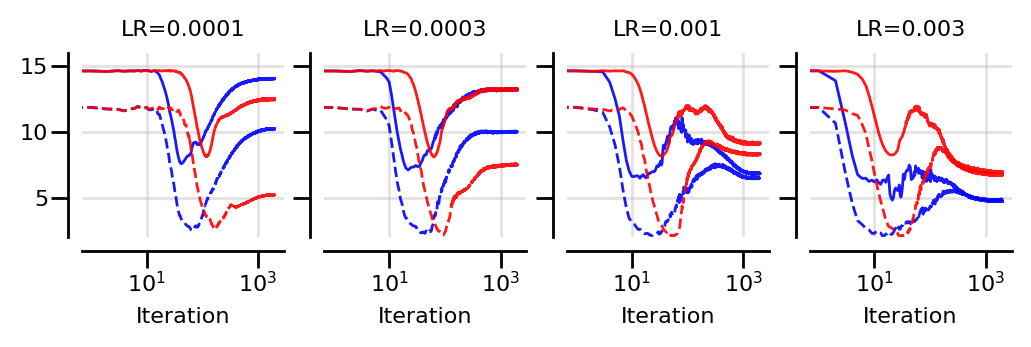

In [93]:


fig, ax = plt.subplots(1, 4, figsize=(6, 1.2), sharey=True)

format_figure(ax, fontsize=8)

for i, LR in enumerate([1e-4, 3e-4, 1e-3, 3e-3]):

    adamw_depth_1_log = all_metrics[("adamw", LR, ROUTER_PLOT_WEIGHT_DECAY, True)]["router_monitor"]
    adamw_depth_0_log = all_metrics[("adamw", LR, ROUTER_PLOT_WEIGHT_DECAY, False)]["router_monitor"]
    muon_depth_1_log = all_metrics[("muon", LR, ROUTER_PLOT_WEIGHT_DECAY, True)]["router_monitor"]
    muon_depth_0_log = all_metrics[("muon", LR, ROUTER_PLOT_WEIGHT_DECAY, False)]["router_monitor"]


    log_dict = {
        "AdamW w/ depth scaling": adamw_depth_1_log,
        "AdamW w/o depth scaling": adamw_depth_0_log,
        "Muon w/ depth scaling": muon_depth_1_log,
        "Muon w/o depth scaling": muon_depth_0_log,
    }
    colors = {"AdamW": "blue", "Muon": "red"}
    linestyles = {"depth-1": "-", "depth-0": "--"}
    for key, metrics in log_dict.items():
        c = colors.get(key.split()[0], None)
        ls = linestyles.get("depth-1" if "w/ depth scaling" in key else "depth-0", None)
        ax[i].plot(2 ** metrics.mean(-1), label=key, 
        color=c, linestyle=ls, 
        linewidth=1.0, alpha=0.9)
    ax[i].set_title(f"LR={LR:g}", fontsize=8)
    ax[i].set_xlabel("Iteration", fontsize=8)
    ax[i].set_xscale("log")
ax[0].set_ylim(2, 16)

Text(0.5, 0, '#Iterations')

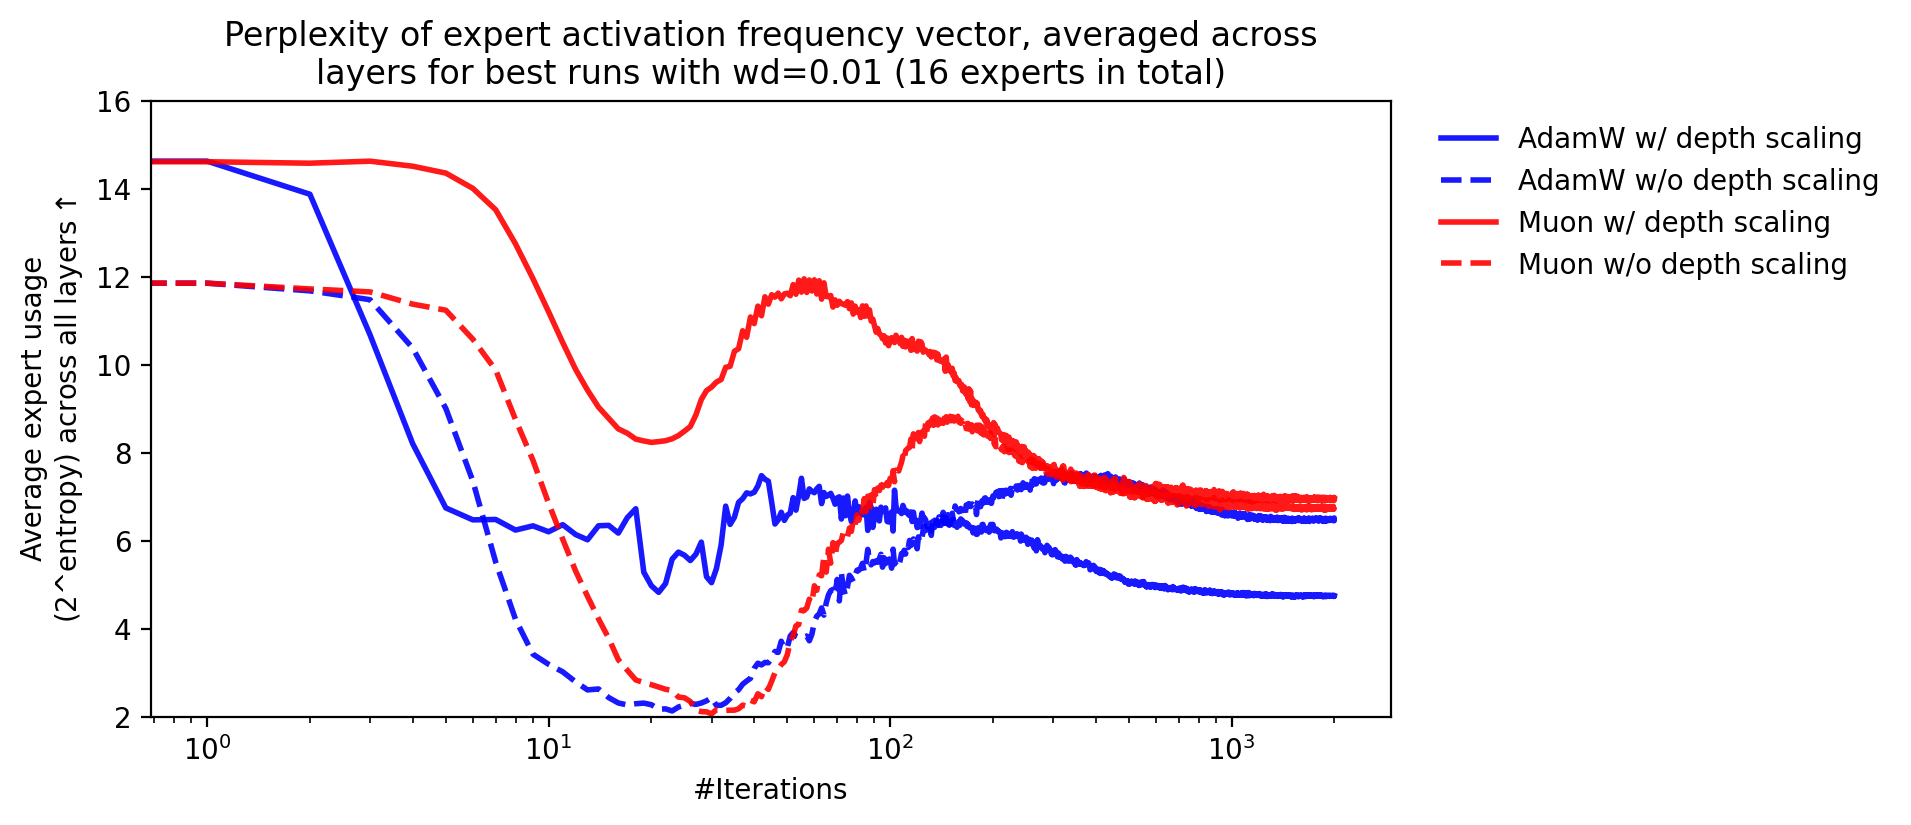

In [85]:
plt.figure(figsize=(8, 4))
colors = {"AdamW": "blue", "Muon": "red"}
linestyles = {"depth-1": "-", "depth-0": "--"}
for key, metrics in log_dict.items():
    c = colors.get(key.split()[0], None)
    ls = linestyles.get("depth-1" if "w/ depth scaling" in key else "depth-0", None)
    plt.plot(2 ** metrics.mean(-1), label=key, 
    color=c, linestyle=ls, 
    linewidth=2.0, alpha=0.9)
plt.legend(frameon=False, fontsize=10, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.ylabel("Average expert usage\n(2^entropy) across all layers" + r"$\uparrow$")
plt.title('Perplexity of expert activation frequency vector, averaged across\nlayers for best runs with wd=0.01 (16 experts in total)')
plt.xscale("log")
plt.ylim(2, 16)
plt.xlabel('#Iterations')

Text(0, 0.5, 'Expert usage (2-16)')

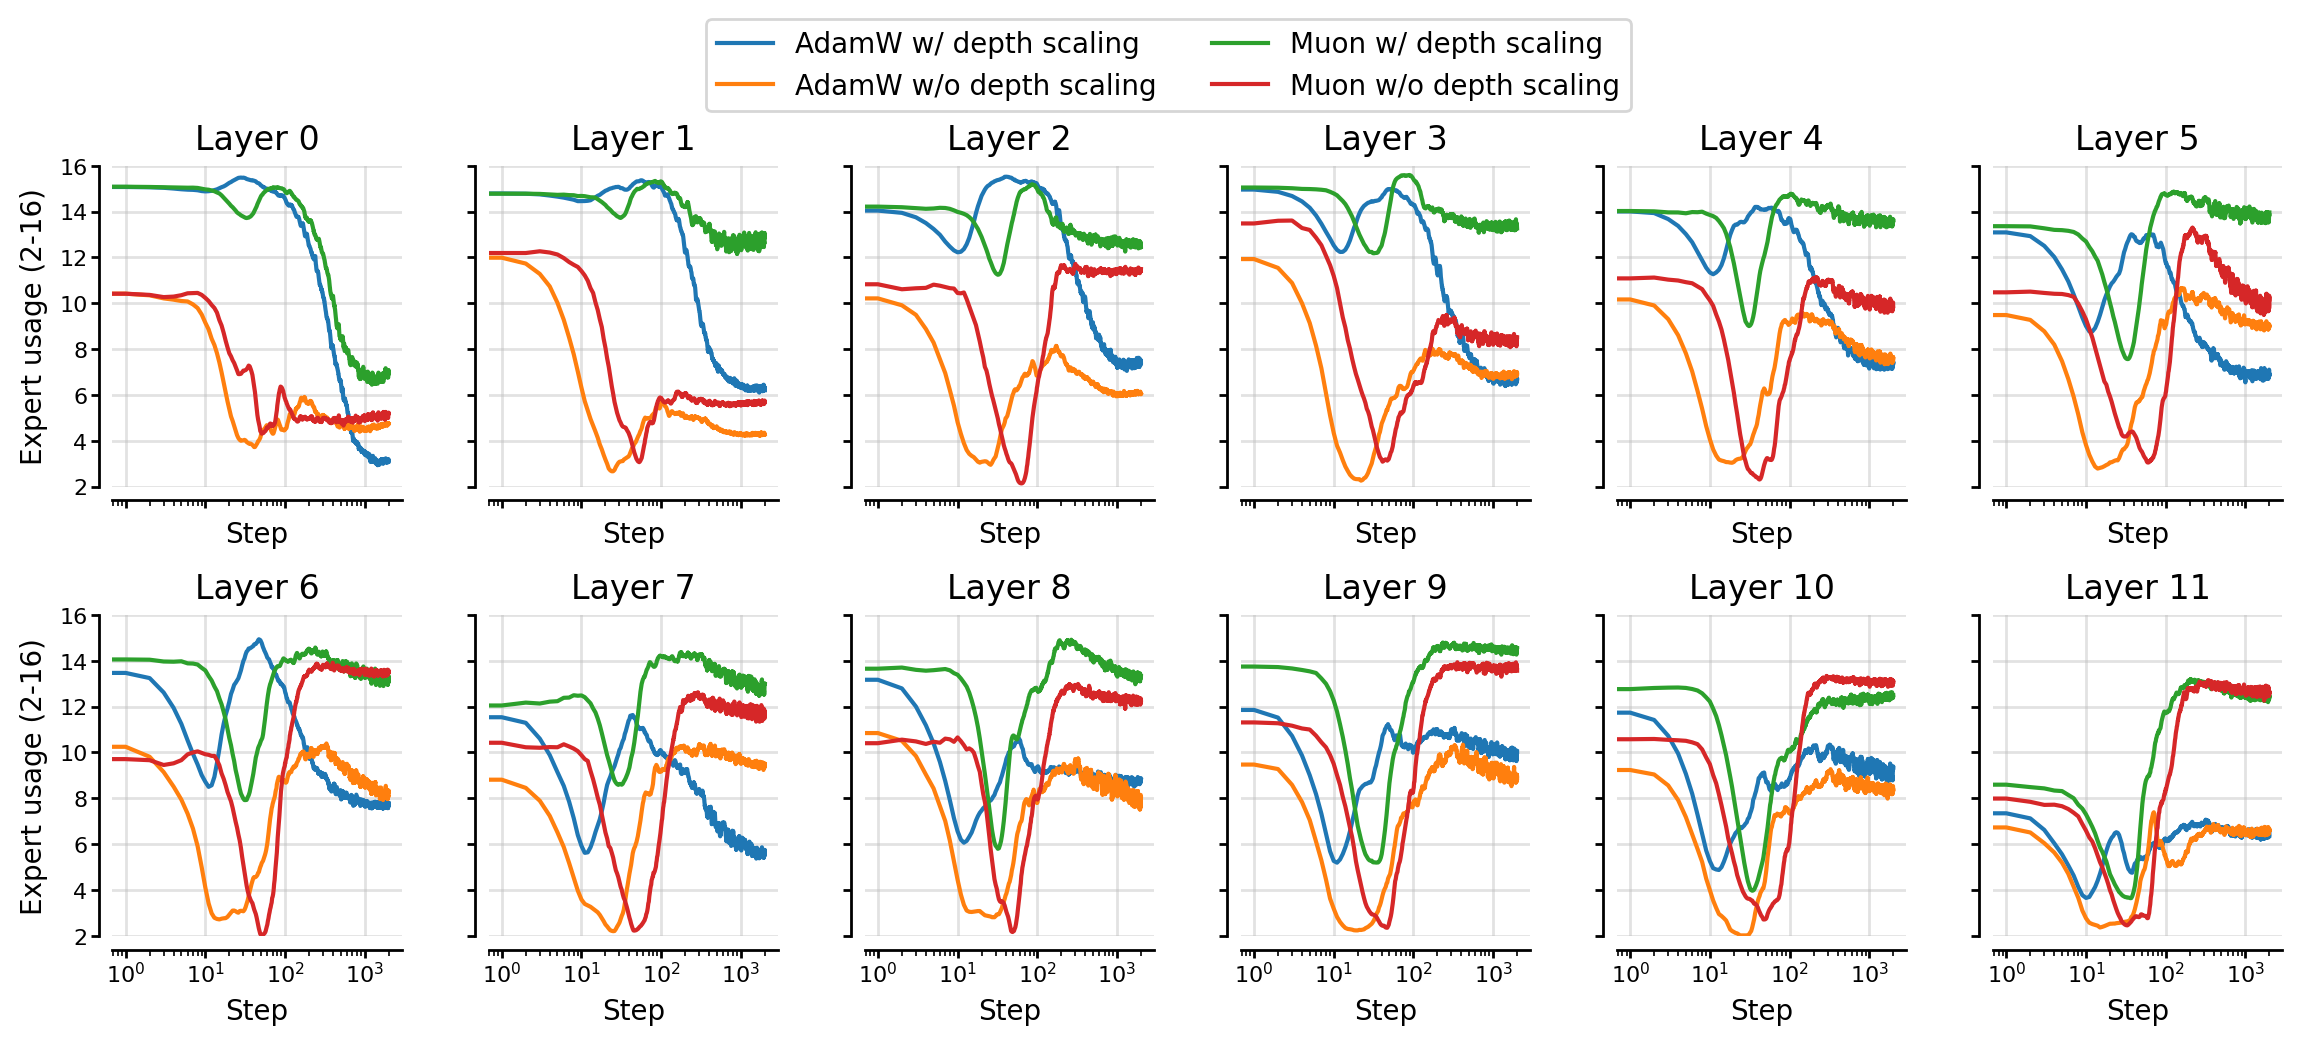

In [91]:
adamw_depth_1_log = all_metrics[("adamw", 1e-3, ROUTER_PLOT_WEIGHT_DECAY, True)]["router_monitor"]
adamw_depth_0_log = all_metrics[("adamw", 1e-3, ROUTER_PLOT_WEIGHT_DECAY, False)]["router_monitor"]
muon_depth_1_log = all_metrics[("muon", 1e-3, ROUTER_PLOT_WEIGHT_DECAY, True)]["router_monitor"]
muon_depth_0_log = all_metrics[("muon", 1e-3, ROUTER_PLOT_WEIGHT_DECAY, False)]["router_monitor"]


# from scipy.ndimage import uniform_filter1d

# def smooth(x):


log_dict = {
    "AdamW w/ depth scaling": adamw_depth_1_log,
    "AdamW w/o depth scaling": adamw_depth_0_log,
    "Muon w/ depth scaling": muon_depth_1_log,
    "Muon w/o depth scaling": muon_depth_0_log,
}

fig, axes = plt.subplots(2, 6, figsize=(14, 5), sharey='row', sharex='col')
fig.subplots_adjust(wspace=0.3, hspace=0.4)
format_figure(axes.flatten(), 8)
for name, log in log_dict.items():
    aux_loss = log[:, :12]
    for i in range(len(aux_loss[0])):
        layer_i_aux_loss = aux_loss[:, i]
        axes[i // 6, i % 6].plot(uniform_filter1d_numpy(2 ** np.array(layer_i_aux_loss), 10), label=name)
        axes[i // 6, i % 6].set_xlabel('Step')
        axes[i // 6, i % 6].set_title(f'Layer {i}')
        # axes[i // 6, i % 6].set_ylim(0, math.log2(model_config.num_experts))
        axes[i // 6, i % 6].set_ylim(2, 16)
        axes[i // 6, i % 6].set_xscale('log')
axes[0, 2].legend(bbox_to_anchor=(1.05, 1.5), loc='upper center', ncols=2)
axes[0, 0].set_ylabel('Expert usage (2-16)')
axes[1, 0].set_ylabel('Expert usage (2-16)')

Text(0, 0.5, 'Expert usage\nperplexity')

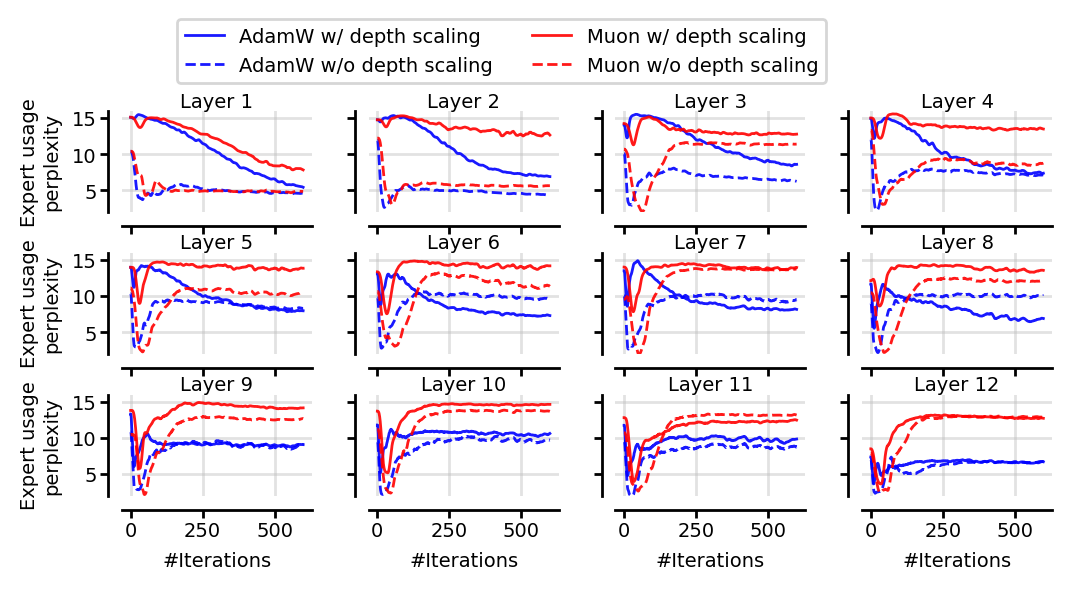

In [102]:
adamw_depth_1_log = all_metrics[("adamw", 1e-3, ROUTER_PLOT_WEIGHT_DECAY, True)]["router_monitor"]
adamw_depth_0_log = all_metrics[("adamw", 1e-3, ROUTER_PLOT_WEIGHT_DECAY, False)]["router_monitor"]
muon_depth_1_log = all_metrics[("muon", 1e-3, ROUTER_PLOT_WEIGHT_DECAY, True)]["router_monitor"]
muon_depth_0_log = all_metrics[("muon", 1e-3, ROUTER_PLOT_WEIGHT_DECAY, False)]["router_monitor"]

# from scipy.ndimage import uniform_filter1d

# def smooth(x):

colors = {"adamw": "blue", "muon": "red"}
linestyles = {"depth-1": "-", "depth-0": "--"}
marker_cycle = ["o", "s", "^", "D", "v", "P"]
depth_label_string = {
    "depth-1": "with depth scaling",
    "depth-0": "without depth scaling",
}

log_dict = {
    "AdamW w/ depth scaling": adamw_depth_1_log,
    "AdamW w/o depth scaling": adamw_depth_0_log,
    "Muon w/ depth scaling": muon_depth_1_log,
    "Muon w/o depth scaling": muon_depth_0_log,
}
FONTSIZE = 7

fig, axes = plt.subplots(3, 4, figsize=(6, 2.5), sharey='row', sharex='col')
ROW, COL = 3, 4
fig.subplots_adjust(wspace=0.3, hspace=0.4)
format_figure(axes.flatten(), FONTSIZE)
for name, log in log_dict.items():
    # aux_loss = log[:, :12]
    aux_loss = log.reshape(log.shape[0], -1, 12).mean(1)
    for i in range(len(aux_loss[0])):
        IDX = i
        layer_i_aux_loss = aux_loss[:, IDX]
        axes[i // COL, i % COL].plot(
            uniform_filter1d_numpy(2 ** np.array(layer_i_aux_loss), 10)[:600], label=name,
            alpha=0.9, linewidth=1.0, color=colors.get(name.split()[0].lower(), None),
            linestyle=linestyles.get("depth-1" if "w/o" not in name else "depth-0", None),
        )
        # 
        axes[i // COL, i % COL].set_title(f'Layer {IDX + 1}', fontsize=FONTSIZE, pad=0.2)
        # axes[IDX // COL, IDX % COL].set_ylim(0, math.log2(model_config.num_experts))
        axes[i // COL, i % COL].set_ylim(2, 16)
        # axes[i // COL, i % COL].set_xscale('log')
        axes[2, i % COL].set_xlabel('#Iterations', fontsize=FONTSIZE)
        # axes[i // COL, i % COL].axvline(x=100, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
axes[0, 0].legend(bbox_to_anchor=(2, 2.0), loc='upper center', ncols=2, fontsize=FONTSIZE)
axes[0, 0].set_ylabel('Expert usage\nperplexity', fontsize=FONTSIZE)
axes[1, 0].set_ylabel('Expert usage\nperplexity', fontsize=FONTSIZE)
axes[2, 0].set_ylabel('Expert usage\nperplexity', fontsize=FONTSIZE)
# save the figure as pdf
# plt.savefig(os.path.join(save_dir, 'router_monitor_perplexity_per_layer_math.pdf'), bbox_inches='tight')
# plt.savefig(os.path.join(save_dir, 'router_monitor_perplexity_per_layer_finewebedu.pdf'), bbox_inches='tight')
# axes[IDX // COL, IDX % COL].set_xlabel('Step')

In [4]:
adamw_depth_1_log = all_metrics[("adamw", 1e-3, ROUTER_PLOT_WEIGHT_DECAY, True)]["router_monitor"]
adamw_depth_0_log = all_metrics[("adamw", 1e-3, ROUTER_PLOT_WEIGHT_DECAY, False)]["router_monitor"]
muon_depth_1_log = all_metrics[("muon", 1e-3, ROUTER_PLOT_WEIGHT_DECAY, True)]["router_monitor"]
muon_depth_0_log = all_metrics[("muon", 1e-3, ROUTER_PLOT_WEIGHT_DECAY, False)]["router_monitor"]

# from scipy.ndimage import uniform_filter1d

# def smooth(x):

colors = {"adamw": "blue", "muon": "red"}
linestyles = {"depth-1": "-", "depth-0": "--"}
marker_cycle = ["o", "s", "^", "D", "v", "P"]
depth_label_string = {
    "depth-1": "with depth scaling",
    "depth-0": "without depth scaling",
}

log_dict = {
    "AdamW w/ depth scaling": adamw_depth_1_log,
    "AdamW w/o depth scaling": adamw_depth_0_log,
    "Muon w/ depth scaling": muon_depth_1_log,
    "Muon w/o depth scaling": muon_depth_0_log,
}
FONTSIZE = 7

fig, axes = plt.subplots(3, 4, figsize=(6, 2.5), sharey='row', sharex='col')
ROW, COL = 3, 4
fig.subplots_adjust(wspace=0.3, hspace=0.4)
format_figure(axes.flatten(), FONTSIZE)
for name, log in log_dict.items():
    # aux_loss = log[:, :12]
    aux_loss = log.reshape(log.shape[0], -1, 12).mean(1)
    for i in range(len(aux_loss[0])):
        IDX = i
        layer_i_aux_loss = aux_loss[:, IDX]
        axes[i // COL, i % COL].plot(
            uniform_filter1d_numpy(2 ** np.array(layer_i_aux_loss), 20)[:1000], label=name,
            alpha=0.9, linewidth=1.0, color=colors.get(name.split()[0].lower(), None),
            linestyle=linestyles.get("depth-1" if "w/o" not in name else "depth-0", None),
        )
        # 
        axes[i // COL, i % COL].set_title(f'Layer {IDX + 1}', fontsize=FONTSIZE, pad=0.2)
        # axes[IDX // COL, IDX % COL].set_ylim(0, math.log2(model_config.num_experts))
        axes[i // COL, i % COL].set_ylim(2, 16)
        # axes[i // COL, i % COL].set_xscale('log')
        axes[2, i % COL].set_xlabel('#Iterations', fontsize=FONTSIZE)
        # axes[i // COL, i % COL].axvline(x=100, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
# axes[0, 0].legend(bbox_to_anchor=(1.05, 1.5), loc='upper left', ncols=2)
axes[0, 0].set_ylabel('Expert usage\nperplexity', fontsize=FONTSIZE)
axes[1, 0].set_ylabel('Expert usage\nperplexity', fontsize=FONTSIZE)
axes[2, 0].set_ylabel('Expert usage\nperplexity', fontsize=FONTSIZE)
# save the figure as pdf
# plt.savefig(os.path.join(save_dir, 'router_monitor_perplexity_per_layer_math.pdf'), bbox_inches='tight')
# plt.savefig(os.path.join(save_dir, 'router_monitor_perplexity_per_layer_finewebedu.pdf'), bbox_inches='tight')
# axes[IDX // COL, IDX % COL].set_xlabel('Step')

NameError: name 'all_metrics' is not defined

In [ ]:
# temp_save_dir = '/home/xwang457/work/nanomoe/temp_log'
# save rows, all_metrics, and all_hidden_state_metrics to temp_save_dir as .npy files
# np.save(os.path.join(temp_save_dir, 'rows.npy'), rows)
# np.save(os.path.join(temp_save_dir, 'all_metrics.npy'), all_metrics)
# np.save(os.path.join(temp_save_dir, 'all_hidden_state_metrics.npy'), all_hidden_state_metrics)

In [90]:
def markdown_table(items: list[dict], columns: list[tuple[str, str]]) -> str:
    header = "| " + " | ".join(title for title, _ in columns) + " |"
    separator = "| " + " | ".join("---" for _ in columns) + " |"
    body = []
    for item in items:
        values = []
        for _, key in columns:
            value = item[key]
            if key in {"learning_rate", "weight_decay", "lr_weight_decay"}:
                value = f"{value:.0e}"
            elif key == "final_loss":
                value = f"{value:.4f}"
            values.append(str(value))
        body.append("| " + " | ".join(values) + " |")
    return "\n".join([header, separator, *body])

rows, skipped, all_metrics, all_hidden_state_metrics = load_final_loss_rows(LOG_DIR)

if TARGET_WEIGHT_DECAYS is None:
    weight_decay_summary = "all weight decays"
else:
    weight_decay_summary = "weight_decay in " + ", ".join(f"{float(wd):.0e}" for wd in sorted(TARGET_WEIGHT_DECAYS))
if TARGET_DEPTH_SCALING is None:
    depth_summary = "all depth settings"
else:
    depth_summary = "depth in " + ", ".join(f"depth-{int(bool(value))}" for value in sorted(TARGET_DEPTH_SCALING))

display(Markdown(f"Loaded {len(rows)} completed runs at step {TARGET_STEP} with grad_accum={TARGET_GRAD_ACCUM}, {weight_decay_summary}, and {depth_summary}."))
display(
    Markdown(
        markdown_table(
            rows,
            [
                ("optimizer", "optimizer"),
                ("learning rate", "learning_rate"),
                ("weight decay", "weight_decay"),
                ("depth", "depth_label"),
                ("lr x wd", "lr_weight_decay"),
                ("final loss", "final_loss"),
                ("run", "run"),
            ],
        )
    )
)

if skipped:
    display(Markdown(f"Skipped {len(skipped)} non-matching or incomplete runs."))
    display(Markdown(markdown_table(skipped, [("run", "run"), ("reason", "reason")])) )


Loaded 32 completed runs at step 2000 with grad_accum=16, weight_decay in 1e-02, and all depth settings.

| optimizer | learning rate | weight decay | depth | lr x wd | final loss | run |
| --- | --- | --- | --- | --- | --- | --- |
| adamw | 1e-04 | 1e-02 | depth-0 | 1e-06 | 2.6196 | opt-adamw_lr-0p0001_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-0 |
| adamw | 3e-04 | 1e-02 | depth-0 | 3e-06 | 1.5872 | opt-adamw_lr-0p0003_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-0 |
| adamw | 1e-03 | 1e-02 | depth-0 | 1e-05 | 1.2366 | opt-adamw_lr-0p001_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-0 |
| adamw | 3e-03 | 1e-02 | depth-0 | 3e-05 | 1.2840 | opt-adamw_lr-0p003_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-0 |
| adamw | 1e-02 | 1e-02 | depth-0 | 1e-04 | 3.8181 | opt-adamw_lr-0p01_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-0 |
| adamw | 3e-02 | 1e-02 | depth-0 | 3e-04 | 4.1729 | opt-adamw_lr-0p03_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-0 |
| adamw | 1e-06 | 1e-02 | depth-1 | 1e-08 | 10.8766 | opt-adamw_lr-1em06_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| adamw | 3e-06 | 1e-02 | depth-1 | 3e-08 | 10.3040 | opt-adamw_lr-3em06_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| adamw | 1e-05 | 1e-02 | depth-1 | 1e-07 | 7.8628 | opt-adamw_lr-1em05_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| adamw | 3e-05 | 1e-02 | depth-1 | 3e-07 | 5.0685 | opt-adamw_lr-3em05_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| adamw | 1e-04 | 1e-02 | depth-1 | 1e-06 | 2.5147 | opt-adamw_lr-0p0001_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| adamw | 3e-04 | 1e-02 | depth-1 | 3e-06 | 1.5546 | opt-adamw_lr-0p0003_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| adamw | 1e-03 | 1e-02 | depth-1 | 1e-05 | 1.2313 | opt-adamw_lr-0p001_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| adamw | 3e-03 | 1e-02 | depth-1 | 3e-05 | 1.1829 | opt-adamw_lr-0p003_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| adamw | 1e-02 | 1e-02 | depth-1 | 1e-04 | 3.8751 | opt-adamw_lr-0p01_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| adamw | 3e-02 | 1e-02 | depth-1 | 3e-04 | 4.1981 | opt-adamw_lr-0p03_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| muon | 1e-04 | 1e-02 | depth-0 | 1e-06 | 3.2730 | opt-muon_lr-0p0001_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-0 |
| muon | 3e-04 | 1e-02 | depth-0 | 3e-06 | 1.4996 | opt-muon_lr-0p0003_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-0 |
| muon | 1e-03 | 1e-02 | depth-0 | 1e-05 | 1.1659 | opt-muon_lr-0p001_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-0 |
| muon | 3e-03 | 1e-02 | depth-0 | 3e-05 | 1.1258 | opt-muon_lr-0p003_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-0 |
| muon | 1e-02 | 1e-02 | depth-0 | 1e-04 | 1.6111 | opt-muon_lr-0p01_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-0 |
| muon | 3e-02 | 1e-02 | depth-0 | 3e-04 | 3.5727 | opt-muon_lr-0p03_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-0 |
| muon | 1e-06 | 1e-02 | depth-1 | 1e-08 | 10.9617 | opt-muon_lr-1em06_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| muon | 3e-06 | 1e-02 | depth-1 | 3e-08 | 10.9259 | opt-muon_lr-3em06_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| muon | 1e-05 | 1e-02 | depth-1 | 1e-07 | 10.4328 | opt-muon_lr-1em05_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| muon | 3e-05 | 1e-02 | depth-1 | 3e-07 | 7.8373 | opt-muon_lr-3em05_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| muon | 1e-04 | 1e-02 | depth-1 | 1e-06 | 3.2191 | opt-muon_lr-0p0001_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| muon | 3e-04 | 1e-02 | depth-1 | 3e-06 | 1.5251 | opt-muon_lr-0p0003_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| muon | 1e-03 | 1e-02 | depth-1 | 1e-05 | 1.1604 | opt-muon_lr-0p001_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| muon | 3e-03 | 1e-02 | depth-1 | 3e-05 | 1.1187 | opt-muon_lr-0p003_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| muon | 1e-02 | 1e-02 | depth-1 | 1e-04 | 1.6231 | opt-muon_lr-0p01_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |
| muon | 3e-02 | 1e-02 | depth-1 | 3e-04 | 3.6304 | opt-muon_lr-0p03_wd-0p01_steps-2000_ga-16_warmup-100_hm-100_depth-1 |

Skipped 5 non-matching or incomplete runs.

| run | reason |
| --- | --- |
| opt-adamw_lr-0p0001_wd-0p01_steps-2000_ga-10_warmup-100_hm-100_depth-1 | grad_accum=10 |
| opt-adamw_lr-0p0001_wd-0p01_steps-20_ga-16_warmup-100_hm-100_depth-1 | iterations=20 |
| opt-adamw_lr-1em06_wd-0p1_steps-2000_ga-16_warmup-100_hm-100_depth-1 | weight_decay=0.1 |
| opt-adamw_lr-3em06_wd-0p1_steps-2000_ga-16_warmup-100_hm-100_depth-1 | weight_decay=0.1 |
| opt-muon_lr-1em06_wd-0p1_steps-2000_ga-16_warmup-100_hm-100_depth-1 | weight_decay=0.1 |

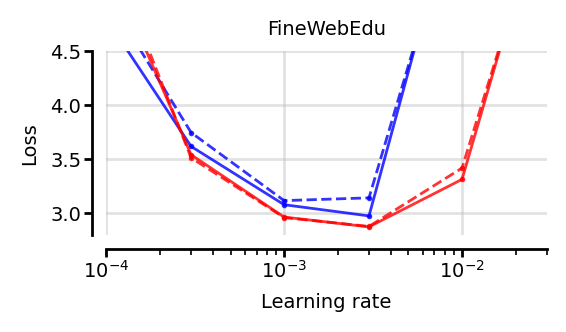

In [9]:
save_dir = '/home/xwang457/work/nanomoe/figs'
plot_rows = rows
if FINAL_LOSS_XLIM is not None:
    x_min, x_max = FINAL_LOSS_XLIM
    plot_rows = [row for row in rows if x_min <= row["learning_rate"] <= x_max]

colors = {"adamw": "blue", "muon": "red"}
linestyles = {"depth-1": "-", "depth-0": "--"}
marker_cycle = ["o", "s", "^", "D", "v", "P"]
depth_label_string = {
    "depth-1": "with depth scaling",
    "depth-0": "without depth scaling",
}
weight_decay_values = sorted({row["weight_decay"] for row in plot_rows})
markers = {wd: marker_cycle[i % len(marker_cycle)] for i, wd in enumerate(weight_decay_values)}

FONTSIZE = 7

fig, ax = plt.subplots(figsize=(3.0, 1.8))
format_figure([ax], FONTSIZE)

series_keys = sorted(
    {(row["optimizer"], row["depth_label"], row["weight_decay"]) for row in plot_rows},
    key=lambda key: (key[0], key[1], key[2]),
)
for optimizer, depth_label, weight_decay in series_keys:
    series_rows = [
        row
        for row in plot_rows
        if row["optimizer"] == optimizer
        and row["depth_label"] == depth_label
        and row["weight_decay"] == weight_decay
    ]
    series_rows = sorted(series_rows, key=lambda row: row["learning_rate"])
    learning_rates = [row["learning_rate"] for row in series_rows]
    final_losses = [row["final_loss"] for row in series_rows]
    ax.plot(
        learning_rates,
        final_losses,
        label=f"{optimizer}, {depth_label_string.get(depth_label, depth_label)}, wd={weight_decay:g}",
        color=colors.get(optimizer),
        linestyle=linestyles.get(depth_label, "-"),
        marker=markers[weight_decay],
        linewidth=1.0,
        alpha=0.8,
        markersize=1,
    )

ax.set_xscale("log")
if FINAL_LOSS_XLIM is not None:
    ax.set_xlim(*FINAL_LOSS_XLIM)
ax.set_xlabel("Learning rate", fontsize=FONTSIZE)
ax.set_ylabel(f"Loss", fontsize=FONTSIZE)
# ax.set_ylim(bottom=2.9, top=5)
ax.set_ylim(bottom=2.8, top=4.5)
# ax.set_title(f"Final loss vs. learning rate at {TARGET_STEP} steps")
# ax.set_ylim(top1e-2)
# ax.set_yscale("log")
# ax.legend(frameon=False, fontsize=8, ncols=2)
ax.set_title('FineWebEdu', fontsize=FONTSIZE)
fig.tight_layout()
# fig.savefig(os.path.join(save_dir, "final_loss_vs_lr_finewebedu.pdf"), bbox_inches="tight")


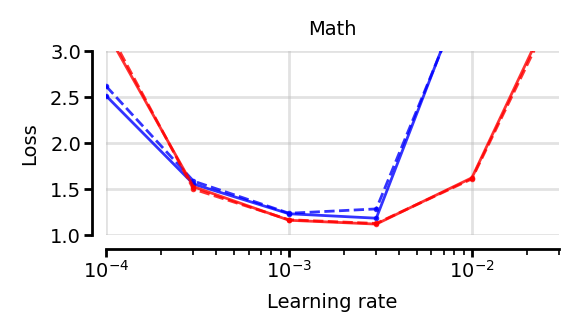

In [181]:
save_dir = '/home/xwang457/work/nanomoe/figs'
plot_rows = rows
if FINAL_LOSS_XLIM is not None:
    x_min, x_max = FINAL_LOSS_XLIM
    plot_rows = [row for row in rows if x_min <= row["learning_rate"] <= x_max]

colors = {"adamw": "blue", "muon": "red"}
linestyles = {"depth-1": "-", "depth-0": "--"}
marker_cycle = ["o", "s", "^", "D", "v", "P"]
depth_label_string = {
    "depth-1": "with depth scaling",
    "depth-0": "without depth scaling",
}
weight_decay_values = sorted({row["weight_decay"] for row in plot_rows})
markers = {wd: marker_cycle[i % len(marker_cycle)] for i, wd in enumerate(weight_decay_values)}

FONTSIZE = 7

# fig, ax = plt.subplots(figsize=(3.0, 2.1))
fig, ax = plt.subplots(figsize=(3.0, 1.8))
format_figure([ax], FONTSIZE)

series_keys = sorted(
    {(row["optimizer"], row["depth_label"], row["weight_decay"]) for row in plot_rows},
    key=lambda key: (key[0], key[1], key[2]),
)
for optimizer, depth_label, weight_decay in series_keys:
    series_rows = [
        row
        for row in plot_rows
        if row["optimizer"] == optimizer
        and row["depth_label"] == depth_label
        and row["weight_decay"] == weight_decay
    ]
    series_rows = sorted(series_rows, key=lambda row: row["learning_rate"])
    learning_rates = [row["learning_rate"] for row in series_rows]
    final_losses = [row["final_loss"] for row in series_rows]
    ax.plot(
        learning_rates,
        final_losses,
        label=f"{optimizer}, {depth_label_string.get(depth_label, depth_label)}, wd={weight_decay:g}",
        color=colors.get(optimizer),
        linestyle=linestyles.get(depth_label, "-"),
        marker=markers[weight_decay],
        linewidth=1.0,
        alpha=0.8,
        markersize=1,
    )

ax.set_xscale("log")
if FINAL_LOSS_XLIM is not None:
    ax.set_xlim(*FINAL_LOSS_XLIM)
ax.set_xlabel("Learning rate", fontsize=FONTSIZE)
ax.set_ylabel(f"Loss", fontsize=FONTSIZE)
ax.set_ylim(bottom=1, top=3)
# ax.set_title(f"Final loss vs. learning rate at {TARGET_STEP} steps")
# ax.set_ylim(top1e-2)
# ax.set_yscale("log")
# ax.legend(frameon=False, fontsize=8, ncols=2)
ax.set_title('Math', fontsize=FONTSIZE)
fig.tight_layout()
fig.savefig(os.path.join(save_dir, "final_loss_vs_lr_math.pdf"), bbox_inches="tight")


In [187]:
from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], color="blue", linestyle="-", linewidth=2, label="AdamW w/ depth scaling"),
    Line2D([0], [0], color="blue", linestyle="--", linewidth=2, label="AdamW w/o depth scaling"),
    Line2D([0], [0], color="red", linestyle="-", linewidth=2, label="Muon w/ depth scaling"),
    Line2D([0], [0], color="red", linestyle="--", linewidth=2, label="Muon w/o depth scaling"),
]

fig, ax = plt.subplots(figsize=(3.6, 1.0))
ax.axis("off")
legend = ax.legend(
    handles=legend_handles,
    loc="center",
    ncol=2,
    frameon=True,
    fontsize=FONTSIZE,
)
fig.tight_layout(pad=0.5)

fig.canvas.draw()
bbox = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())

legend_path = os.path.join(save_dir, "legend_blue_red_solid_dash.pdf")
fig.savefig(legend_path, bbox_inches=bbox, pad_inches=0)
plt.close(fig)
legend_path

'/home/xwang457/work/nanomoe/figs/legend_blue_red_solid_dash.pdf'

# batch size ablation

In [45]:
all_metrics_48.keys()

dict_keys([('adamw', 0.0001, 0.01, False), ('adamw', 0.0001, 0.01, True), ('adamw', 0.0003, 0.01, False), ('adamw', 0.0003, 0.01, True), ('adamw', 0.001, 0.01, False), ('adamw', 0.001, 0.01, True), ('adamw', 0.003, 0.01, False), ('adamw', 0.003, 0.01, True), ('adamw', 0.01, 0.01, True), ('adamw', 0.03, 0.01, False), ('adamw', 0.03, 0.01, True), ('muon', 0.0001, 0.01, True), ('muon', 0.0003, 0.01, True), ('muon', 0.001, 0.01, False), ('muon', 0.001, 0.01, True), ('muon', 0.003, 0.01, False), ('muon', 0.003, 0.01, True), ('muon', 0.01, 0.01, True), ('muon', 0.03, 0.01, True)])

In [79]:
LOG_DIR = Path("/home/xwang457/work/nanomoe/pretrain_log_with_ckpt")
TARGET_STEP = 2000

TARGET_WEIGHT_DECAYS = {0.01}  # Set to None, {0.01}, or {0.1} to filter decay sweeps.
TARGET_DEPTH_SCALING = None  # Set to {True} or {False} to filter depth scaling.
FINAL_LOSS_XLIM = (1e-4, 3e-2)  # Set to None to show all learning rates.
ROUTER_PLOT_WEIGHT_DECAY = 0.01
ROUTER_PLOT_DEPTH_SCALING = True
FILE_PREFIX = "data-finewebedu_seed-42_opt-*"
OPTIMIZERS = {"adamw", "muon"}
TARGET_GRAD_ACCUM = 48
_, _, all_metrics_48, _ = load_final_loss_rows(LOG_DIR)

TARGET_GRAD_ACCUM = 32
_, _, all_metrics_32, _ = load_final_loss_rows(LOG_DIR)

temp_save_dir = '/home/xwang457/work/nanomoe/temp_log'
all_metrics_20 = np.load(os.path.join(temp_save_dir, 'all_metrics.npy'), allow_pickle=True).item()

log_dict = {}

for optim in OPTIMIZERS:
    key = (optim, 1e-3, ROUTER_PLOT_WEIGHT_DECAY, True)
    if key not in all_metrics_20 and grad_accum == 20:
        print(f"Warning: missing metrics for {key} in grad_accum=20")
    if key not in all_metrics_32 and grad_accum == 32:
        print(f"Warning: missing metrics for {key} in grad_accum=32")
    if key not in all_metrics_48 and grad_accum == 48:
        print(f"Warning: missing metrics for {key} in grad_accum=48")
    log_dict[(optim)] = {
        20: all_metrics_20.get(key),
        32: all_metrics_32.get(key),
        48: all_metrics_48.get(key),
    }

colors_adamw = ['#6baed6','#3182bd','#08519c']
colors_muon = ['#fb6a4a','#de2d26','#a50f15']

In [40]:
log[grad_accum]['router_monitor']

array([[2.98573971, 3.54104185, 3.61393332, ..., 3.63172865, 3.52550364,
        3.61680865],
       [3.00094533, 3.33223677, 3.58141923, ..., 3.73474741, 3.73818541,
        3.68842793],
       [3.00292778, 3.46556711, 3.68035197, ..., 3.67570972, 3.64116478,
        3.72596645],
       ...,
       [1.35114419, 2.77217031, 3.31368971, ..., 3.45078278, 3.17913198,
        2.96199274],
       [1.35634637, 2.80594516, 3.32503533, ..., 3.38856196, 3.01716852,
        2.73930407],
       [1.32468331, 2.77506614, 3.31161594, ..., 3.34728146, 3.05451035,
        2.74771929]], shape=(2000, 240))

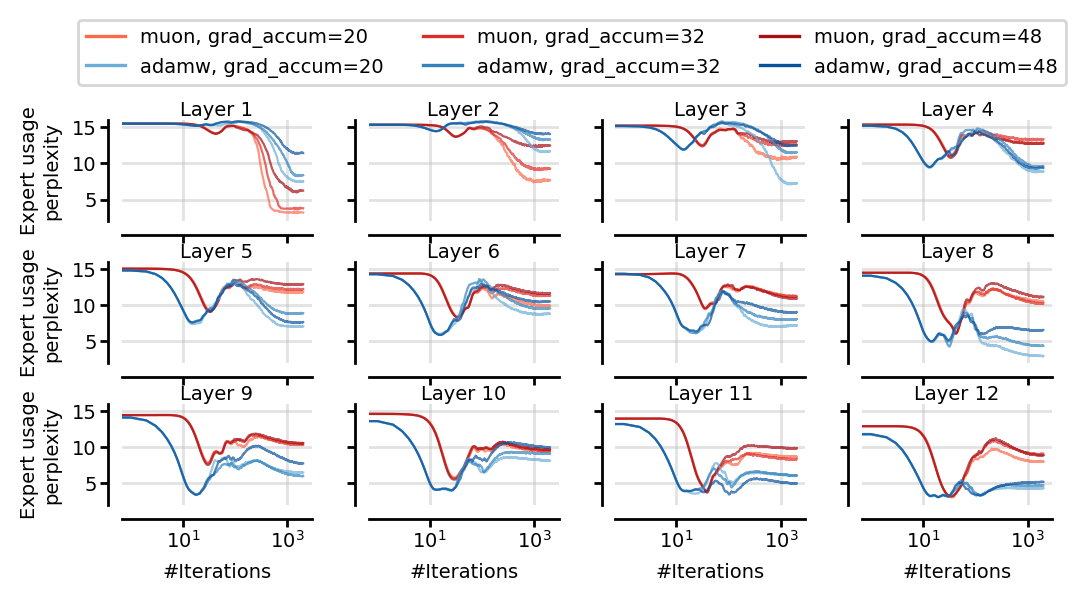

In [80]:
FONTSIZE = 7

fig, axes = plt.subplots(3, 4, figsize=(6, 2.5), sharey='row', sharex='col')
ROW, COL = 3, 4
fig.subplots_adjust(wspace=0.3, hspace=0.4)
format_figure(axes.flatten(), FONTSIZE)
for name, log in log_dict.items():
    for gid, grad_accum in enumerate([20, 32, 48]):
        # aux_loss = log[:, :12]
        _log = log[grad_accum]['router_monitor']
        aux_loss = _log.reshape(_log.shape[0], -1, 12).mean(1)
        for i in range(len(aux_loss[0])):
            IDX = i
            layer_i_aux_loss = aux_loss[:, IDX]
            C = colors_adamw[gid] if name == "adamw" else colors_muon[gid]
            axes[i // COL, i % COL].plot(
                uniform_filter1d_numpy(2 ** np.array(layer_i_aux_loss), 10)[:], 
                alpha=0.7, linewidth=0.8, color=C,
                linestyle=linestyles.get("depth-1" if "w/o" not in name else "depth-0", None),
                label=f"{name}, grad_accum={grad_accum}"
            )
            # 
            axes[i // COL, i % COL].set_title(f'Layer {IDX + 1}', fontsize=FONTSIZE, pad=0.2)
            # axes[IDX // COL, IDX % COL].set_ylim(0, math.log2(model_config.num_experts))
            axes[i // COL, i % COL].set_ylim(2, 16)
            axes[i // COL, i % COL].set_xscale('log')
            axes[2, i % COL].set_xlabel('#Iterations', fontsize=FONTSIZE)
        # axes[i // COL, i % COL].axvline(x=100, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
    axes[0, 0].set_ylabel('Expert usage\nperplexity', fontsize=FONTSIZE)
    axes[1, 0].set_ylabel('Expert usage\nperplexity', fontsize=FONTSIZE)
    axes[2, 0].set_ylabel('Expert usage\nperplexity', fontsize=FONTSIZE)
# make legend
# import line2d
from matplotlib.lines import Line2D
handles = []
for gid, grad_accum in enumerate([20, 32, 48]):
    for optim in OPTIMIZERS:
        C = colors_adamw[gid] if optim == "adamw" else colors_muon[gid]
        handles.append(Line2D([0], [0], color=C, linewidth=1.2, label=f"{optim}, grad_accum={grad_accum}"))
fig.legend(handles=handles, bbox_to_anchor=(0.5, 1.1), loc='upper center', ncols=3, fontsize=FONTSIZE)
# save the figure as pdf